<H1>Example of bad strategy (p-hacking)<H1>

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Parameters
btc_symbol = "BTC-USD"
etf_symbol = "BITO"
start = "2024-01-01"
end   = "2024-12-31"

# Fetch historical data
btc = yf.download(btc_symbol, start=start, end=end, interval="1d")['Close']
etf = yf.download(etf_symbol, start=start, end=end, interval="1d")['Close']

# Align
data = pd.concat([btc, etf], axis=1)
data = data.dropna()

data.head(10)

C:\Users\Johan\AppData\Local\Temp\ipykernel_4668\3537410461.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download(btc_symbol, start=start, end=end, interval="1d")['Close']
[*********************100%***********************]  1 of 1 completed
C:\Users\Johan\AppData\Local\Temp\ipykernel_4668\3537410461.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  etf = yf.download(etf_symbol, start=start, end=end, interval="1d")['Close']
[*********************100%***********************]  1 of 1 completed


Ticker,BTC-USD,BITO
Date,,
2024-01-02,44957.968750,8.757142
2024-01-03,42848.175781,8.321086
2024-01-04,44179.921875,8.609124
2024-01-05,44162.691406,8.565117
2024-01-08,46970.503906,9.141192
2024-01-09,46139.730469,9.089186
2024-01-10,46627.777344,8.945164
2024-01-11,46368.585938,8.933164
2024-01-12,42853.167969,8.425098


In [15]:
btc_per_share = 0.0005 

data["etf_nav"] = data["BTC-USD"] * btc_per_share
data["premium"] = data["BITO"] / data["etf_nav"] - 1
data[["BTC-USD", "BITO", "etf_nav", "premium"]].head()

Ticker,BTC-USD,BITO,etf_nav,premium
Date,,,,
2024-01-02,44957.968750,8.757142,22.478984,-0.610430
2024-01-03,42848.175781,8.321086,21.424088,-0.611601
2024-01-04,44179.921875,8.609124,22.089961,-0.610270
2024-01-05,44162.691406,8.565117,22.081346,-0.612111
2024-01-08,46970.503906,9.141192,23.485252,-0.610769


In [22]:
open_th = 0.005
close_th = 0.005

position = 0   # +1 = long ETF / short BTC, -1 = long BTC / short ETF
pnl = []
entry_price = None

for t in range(len(data)):
    prem = data["premium"].iloc[t]
    btc_p = data["BTC-USD"].iloc[t]
    etf_p = data["BITO"].iloc[t]
    
    if position == 0:
        if prem > open_th:
            position = -1  # long BTC / short ETF
            entry_price = (btc_p, etf_p)
        elif prem < -open_th:
            position = 1   # long ETF / short BTC
            entry_price = (btc_p, etf_p)
        pnl.append(0)
        
    elif position == 1:
        # Close if premium normalized
        if abs(prem) < close_th:
            pnl.append((btc_p - entry_price[0]) - (etf_p - entry_price[1]))
            position = 0
        else:
            pnl.append((btc_p - entry_price[0]) - (etf_p - entry_price[1]))
            
    elif position == -1:
        if abs(prem) < close_th:
            pnl.append((etf_p - entry_price[1]) - (btc_p - entry_price[0]))
            position = 0
        else:
            pnl.append((etf_p - entry_price[1]) - (btc_p - entry_price[0]))
            
data["pnl"] = pnl
data["equity"] = data["pnl"].cumsum()

Total PnL: 5239464.228977203
Number of trades (approx): 250


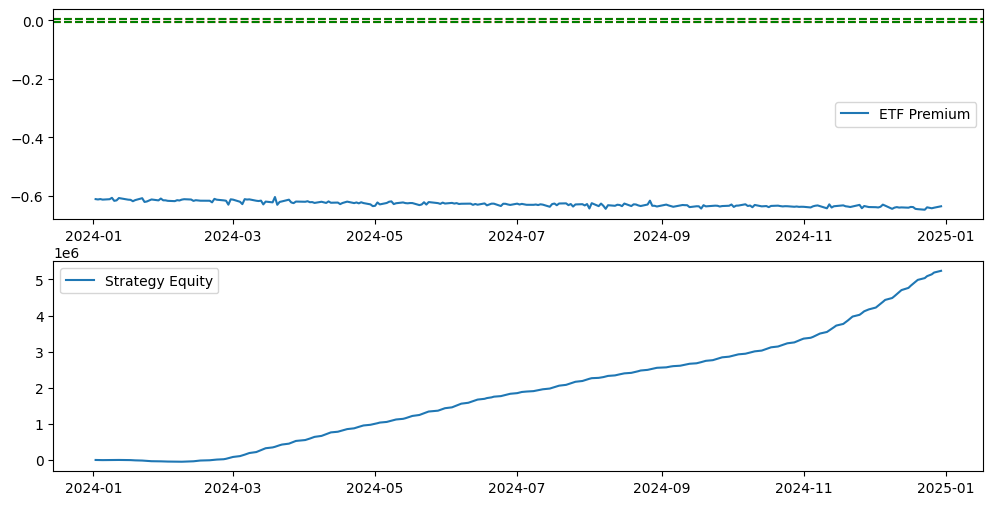

In [23]:
print("Total PnL:", data["equity"].iloc[-1])
print("Number of trades (approx):", (data["pnl"]!=0).sum())

plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
plt.plot(data.index, data["premium"], label="ETF Premium")
plt.axhline(open_th, color="red", linestyle="--")
plt.axhline(-open_th, color="red", linestyle="--")
plt.axhline(close_th, color="green", linestyle="--")
plt.axhline(-close_th, color="green", linestyle="--")
plt.legend()

plt.subplot(2,1,2)
plt.plot(data.index, data["equity"], label="Strategy Equity")
plt.legend()
plt.show()